# 2-D linear-quadratic-Gaussian control

The canonical analytical benchmark for multi-dim DP. Discrete-time
LQR with stochastic noise, two-dim state, scalar control.

## Problem

State $x \in \mathbb{R}^2$, action $u \in \mathbb{R}$, scalar shock
$w \sim \mathcal{N}(0, 1)$. Dynamics and reward:

$$ x_{t+1} = A x_t + B u_t + C w_t, \qquad
   r_t(x, u) = -\bigl(x^\top Q x + u^\top R u\bigr). $$

bellgrid maximises, so the closed-form value function is

$$ V_t(x) = -\bigl(x^\top P_t x + c_t\bigr) $$

where $P_t$ comes from the **discrete-time Riccati recursion** (sweeping
backward from $P_T = Q$),

$$ K_t = (R + \gamma B^\top P_{t+1} B)^{-1} \gamma B^\top P_{t+1} A, $$

$$ P_t = Q + \gamma A^\top P_{t+1} A - \gamma A^\top P_{t+1} B K_t, $$

$$ c_t = \gamma \bigl(\,C^\top P_{t+1} C + c_{t+1}\bigr), $$

and the optimal policy is linear in $x$:

$$ u^*_t(x) = -K_t x. $$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    Problem,
    solve,
)
from bellgrid.grids import RegularGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
A_MAT = np.array([[0.9, 0.1], [0.05, 0.85]])
B_MAT = np.array([[1.0], [0.5]])
C_MAT = np.array([[0.1], [0.05]])
Q_MAT = np.eye(2)
R_MAT = np.array([[0.1]])
GAMMA = 0.95
T = 15

## Closed-form Riccati reference

In [3]:
def riccati_lqg(A, B, C, Q, R, gamma, T):
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)
    Q = np.asarray(Q, dtype=np.float64)
    R = np.asarray(R, dtype=np.float64)

    P = [None] * (T + 1)
    K = [None] * T
    c = [0.0] * (T + 1)
    P[T] = Q

    for t in range(T - 1, -1, -1):
        Rg = R + gamma * B.T @ P[t + 1] @ B
        K[t] = np.linalg.solve(Rg, gamma * B.T @ P[t + 1] @ A)
        P[t] = Q + gamma * A.T @ P[t + 1] @ A - gamma * A.T @ P[t + 1] @ B @ K[t]
        c[t] = gamma * (float((C.T @ P[t + 1] @ C).item()) + c[t + 1])
    return P, K, c


P_list, K_list, c_list = riccati_lqg(A_MAT, B_MAT, C_MAT, Q_MAT, R_MAT, GAMMA, T)
P0, K0, c0 = P_list[0], K_list[0], c_list[0]
print(f"P_0 =\n{P0}")
print(f"K_0 = {K0}")
print(f"c_0 = {c0:.6f}")

P_0 =
[[ 1.36068736 -0.59125668]
 [-0.59125668  2.25686841]]
K_0 = [[0.68483182 0.39134236]]
c_0 = 0.135609


## Bellgrid problem

Two `ContinuousState`s (`x1`, `x2`), a scalar `ContinuousAction`,
and one `Normal` shock. The closed-form $V_T = -x^\top Q x$ goes
into `terminal_reward`.

In [4]:
A_t = torch.as_tensor(A_MAT, dtype=torch.float64)
B_t = torch.as_tensor(B_MAT.flatten(), dtype=torch.float64)
C_t = torch.as_tensor(C_MAT.flatten(), dtype=torch.float64)


def transition(state, action, shock, _t):
    x1 = state["x1"]
    x2 = state["x2"]
    u = action["u"]
    w = shock["w"]
    return {
        "x1": A_t[0, 0] * x1 + A_t[0, 1] * x2 + B_t[0] * u + C_t[0] * w,
        "x2": A_t[1, 0] * x1 + A_t[1, 1] * x2 + B_t[1] * u + C_t[1] * w,
    }


def reward(state, action, _shock, _t):
    return -(state["x1"]**2 + state["x2"]**2 + 0.1 * action["u"]**2)


def terminal_reward(state):
    return -(state["x1"]**2 + state["x2"]**2)


problem = Problem(
    states=[
        ContinuousState("x1", range=(-3.0, 3.0)),
        ContinuousState("x2", range=(-3.0, 3.0)),
    ],
    actions=[ContinuousAction("u", bounds=(-5.0, 5.0))],
    transition=transition,
    reward=reward,
    shocks=[Normal("w", sigma=1.0)],
    horizon=range(0, T),
    discount=GAMMA,
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={
        "x1": RegularGrid(n=129),
        "x2": RegularGrid(n=129),
    },
    action_grid={"u": RegularGrid(n=101)},
    solver=BackwardInduction(n_quad=7),
)

## Value function: bellgrid vs Riccati

Heatmaps of $V_0(x_1, x_2)$ side-by-side, plus the residual error.
Since LQG values are quadratic in $x$ and we use bilinear interpolation,
the residual is dominated by the $\mathcal{O}(h^2)$ multilinear bias
accumulated across the $T = 15$ backward sweeps.

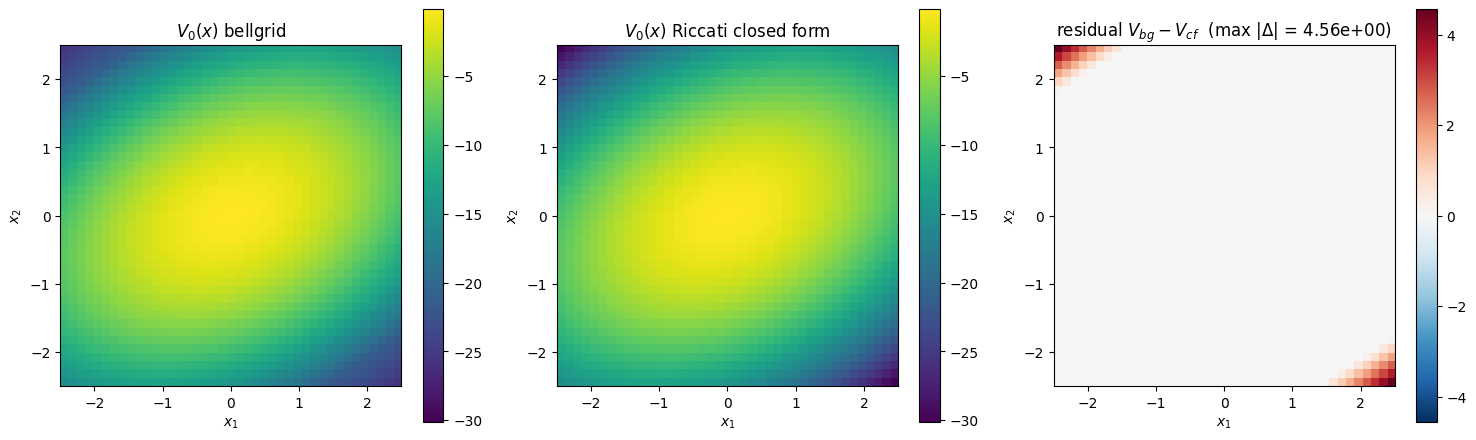

In [5]:
n_grid = 41
x_axis = np.linspace(-2.5, 2.5, n_grid)
X1, X2 = np.meshgrid(x_axis, x_axis, indexing="ij")

# bellgrid V
state_q = {
    "x1": torch.tensor(X1.flatten(), dtype=torch.float64),
    "x2": torch.tensor(X2.flatten(), dtype=torch.float64),
}
V_bg = value(state_q, t=0).numpy().reshape(n_grid, n_grid)

# Closed-form V
V_cf = np.empty_like(V_bg)
for i in range(n_grid):
    for j in range(n_grid):
        x = np.array([X1[i, j], X2[i, j]])
        V_cf[i, j] = -(x.T @ P0 @ x + c0)

V_err = V_bg - V_cf

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmin = min(V_bg.min(), V_cf.min())
vmax = max(V_bg.max(), V_cf.max())

for ax, data, title in zip(
    axes[:2],
    (V_bg, V_cf),
    ("$V_0(x)$ bellgrid", "$V_0(x)$ Riccati closed form"),
):
    im = ax.imshow(
        data.T, extent=[x_axis[0], x_axis[-1], x_axis[0], x_axis[-1]],
        origin="lower", cmap="viridis", vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

err_max = np.abs(V_err).max()
im = axes[2].imshow(
    V_err.T, extent=[x_axis[0], x_axis[-1], x_axis[0], x_axis[-1]],
    origin="lower", cmap="RdBu_r", vmin=-err_max, vmax=err_max,
)
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("$x_2$")
axes[2].set_title(f"residual $V_{{bg}} - V_{{cf}}$  (max |Δ| = {err_max:.2e})")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## Optimal action: bellgrid vs Riccati

Both heatmaps should show the same linear gradient in $x$ (since the
closed-form $u^* = -K_0 x$ is linear). Action-grid spacing introduces
a small step-function pattern in the bellgrid heatmap.

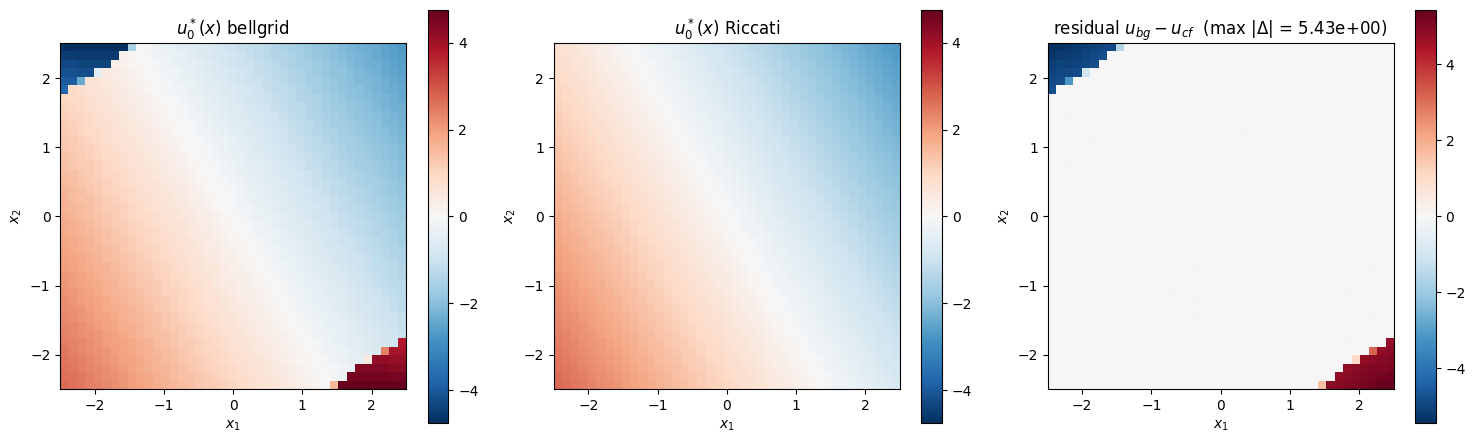

In [6]:
u_bg = policy(state_q, t=0)["u"].numpy().reshape(n_grid, n_grid)

# Closed-form policy
u_cf = np.empty_like(u_bg)
for i in range(n_grid):
    for j in range(n_grid):
        x = np.array([X1[i, j], X2[i, j]])
        u_cf[i, j] = -(K0 @ x).item()

u_err = u_bg - u_cf

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmin = min(u_bg.min(), u_cf.min())
vmax = max(u_bg.max(), u_cf.max())
amp = max(abs(vmin), abs(vmax))

for ax, data, title in zip(
    axes[:2],
    (u_bg, u_cf),
    ("$u^*_0(x)$ bellgrid", "$u^*_0(x)$ Riccati"),
):
    im = ax.imshow(
        data.T, extent=[x_axis[0], x_axis[-1], x_axis[0], x_axis[-1]],
        origin="lower", cmap="RdBu_r", vmin=-amp, vmax=amp,
    )
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

err_max = np.abs(u_err).max()
im = axes[2].imshow(
    u_err.T, extent=[x_axis[0], x_axis[-1], x_axis[0], x_axis[-1]],
    origin="lower", cmap="RdBu_r", vmin=-err_max, vmax=err_max,
)
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("$x_2$")
axes[2].set_title(f"residual $u_{{bg}} - u_{{cf}}$  (max |Δ| = {err_max:.2e})")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## Slice through the origin: line plots

Along $x_2 = 0$, both the value function and the optimal policy
reduce to scalar functions of $x_1$. Stacked plots make the
bellgrid–vs-Riccati overlay easy to read.

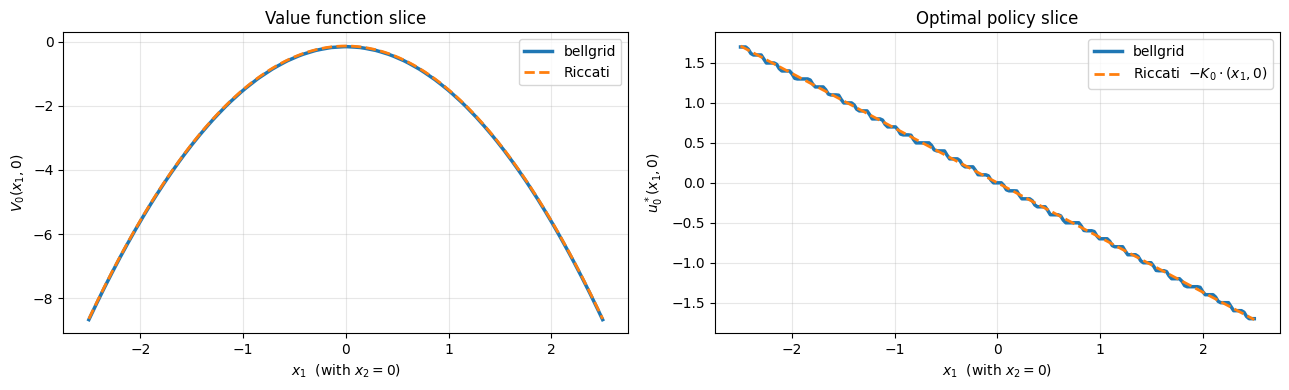

In [7]:
x1_line = np.linspace(-2.5, 2.5, 200)
state_line = {
    "x1": torch.tensor(x1_line, dtype=torch.float64),
    "x2": torch.zeros_like(torch.tensor(x1_line, dtype=torch.float64)),
}
V_line_bg = value(state_line, t=0).numpy()
u_line_bg = policy(state_line, t=0)["u"].numpy()

V_line_cf = np.array([
    -(np.array([x, 0]).T @ P0 @ np.array([x, 0]) + c0) for x in x1_line
])
u_line_cf = np.array([
    -(K0 @ np.array([x, 0])).item() for x in x1_line
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x1_line, V_line_bg, lw=2.5, label="bellgrid")
axes[0].plot(x1_line, V_line_cf, ls="--", lw=2, label="Riccati")
axes[0].set_xlabel("$x_1$  (with $x_2 = 0$)")
axes[0].set_ylabel("$V_0(x_1, 0)$")
axes[0].set_title("Value function slice")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x1_line, u_line_bg, lw=2.5, label="bellgrid")
axes[1].plot(x1_line, u_line_cf, ls="--", lw=2, label="Riccati  $-K_0 \\cdot (x_1, 0)$")
axes[1].set_xlabel("$x_1$  (with $x_2 = 0$)")
axes[1].set_ylabel("$u^*_0(x_1, 0)$")
axes[1].set_title("Optimal policy slice")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Convergence: V error vs state-grid resolution

Empirically the V error decays at roughly $\mathcal{O}(h^{1.7})$ —
a little worse than the textbook $\mathcal{O}(h^2)$ because the
multilinear-on-quadratic bias accumulates across the $T$ backward
sweeps.

n_state =   33    h = 0.1875    max |Δ V| = 2.4295e-01
n_state =   65    h = 0.0938    max |Δ V| = 7.0443e-02
n_state =  129    h = 0.0469    max |Δ V| = 2.5802e-02


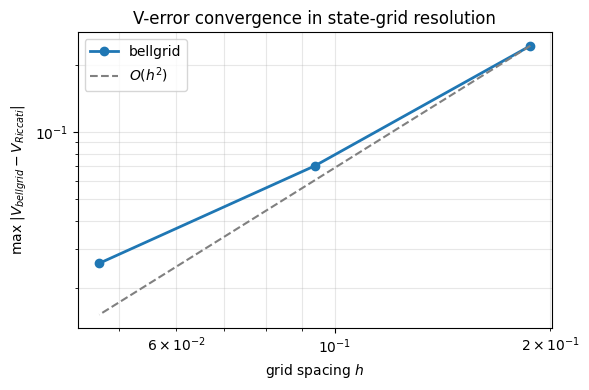

In [8]:
test_states = [(0.0, 0.0), (-1.0, 1.0), (1.5, -1.5)]


def max_v_err(n):
    p, v = solve(
        problem,
        state_grid={"x1": RegularGrid(n=n), "x2": RegularGrid(n=n)},
        action_grid={"u": RegularGrid(n=101)},
        solver=BackwardInduction(n_quad=7),
    )
    err = 0.0
    for (x1, x2) in test_states:
        v_bg = v({
            "x1": torch.tensor([x1], dtype=torch.float64),
            "x2": torch.tensor([x2], dtype=torch.float64),
        }, t=0).item()
        x = np.array([x1, x2])
        v_cf = -(x.T @ P0 @ x + c0)
        err = max(err, abs(v_bg - v_cf))
    return err


ns = [33, 65, 129]
hs = [6.0 / (n - 1) for n in ns]
errs = [max_v_err(n) for n in ns]

for n, h, e in zip(ns, hs, errs):
    print(f"n_state = {n:>4}    h = {h:.4f}    max |Δ V| = {e:.4e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(hs, errs, "o-", lw=2, label="bellgrid")
ax.loglog(hs, errs[0] * (np.array(hs) / hs[0]) ** 2, "--", color="gray", label="$O(h^2)$")
ax.set_xlabel("grid spacing $h$")
ax.set_ylabel("max $|V_{bellgrid} - V_{Riccati}|$")
ax.set_title("V-error convergence in state-grid resolution")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()